# Fast CXI Spectral Ghost Imaging

### This notebook is a conglomeration of the pump probe notebook along with a translated version of the ghost imaging analysis (sans some steps) in python.

Note: It does not separate shots based on time binning. Either, I make a new notebook for that or we just use this notebook multiple times to determine time-dependent data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import xrayscatteringtools as xrst
import warnings
from matplotlib.colors import LogNorm
from scipy.linalg import toeplitz
from scipy.optimize import nnls
import scipy.io as scio
xrst.enable_underscore_cleanup()

In [4]:
#########################################
#        SET ALL PARAMETERS HERE        #
#########################################

# Runs
RUN_NUMS_BOUNDS = [104,150]        # DMP
RUN_NUMS_EXCL = []

# Filter cutoffs
J4M_CUTOFF = [40, 190];
DG2_CUTOFF = [1e5, 5.2e5];
PULSE_ENERGY_CUTOFF = [0.7, 2.4] # mJ
SPEC_CUTOFF = [1.3e7, 4.8e7];
TT_EDGEPOS_CUTOFF = [300, 850]
TT_AMP_CUTOFF = [0.6, 1.02]   # mJ     
TT_WIDTH_CUTOFF = [90, 390]
FILTER_PLOT_SCALING = 'log' # 'linear'

# Additional spectral filtering
SPECTRUM_CROP_FACTOR = 0.8
SPECTRUM_FRACTION_INSIDE = 0.995
SPECTRUM_PLOT_FILTER = True
# Spectrometer offset
SPECTRUM_OFFSET = 0
# Energy downsampling
SPECTRUM_N_REBIN = 8
SPECTRUM_CROP_REBIN = (0, 256)
SPECTRUM_PLOT_REBIN = True

# Time
TIME_BIN_EDGES = [-3,-2,-1.1,0,5]
TT_CORRECTION = True
TT_PLOT = True
T0 = -1.6

# Ghost imaging
GI_LAMBDA = 3
GI_PLOT_A = True
GI_E_MIN, GI_E_MAX = 9.65, 9.68
GI_PLOT_FILTER = True
GI_PLOT_SCATTER = True
GI_PLOT_ABS = True
GI_VMAX_ABS = 0.5e-7  # set to a float to fix the colour scale, None for auto
GI_ELASTIC_RANGE  = (0, 1)     # energy-loss range in eV for elastic
GI_INELASTIC_RANGE = (1, 30)   # energy-loss range in eV for inelastic
GI_TIME_VOFFSET = 5
GI_Q_INTEGRATE_RANGE = (4, None)   # q-index range to integrate over (skip low-q); None = end
# GI_CLIM_PCT = 2                # symmetric colour limit (%)
# GI_CLIM_PCT_IN = 50

## Load the data

In [5]:
# Runs

# Set run numbers & paths
runNumbers = [x for x in np.arange(RUN_NUMS_BOUNDS[0],RUN_NUMS_BOUNDS[1]+1) if x not in RUN_NUMS_EXCL]
folders = xrst.get_data_paths(int(runNumbers[0])) # Defaults to the info in config.yaml. You can overwrite this with strings, character arrays, or lists of either.

# Data keys
# loaded for each shot & stored per shot 
_keys_to_combine = [
    'jungfrau4M/azav_mask0_azav',                           # Azimuthal Averages
    'jungfrau4M/azav_mask1_azav',
    'ebeam/photon_energy',                                  # Photon energy
    'tt/FLTPOS', 'tt/AMPL', 'tt/FLTPOSFWHM',                # Timetool data
    # 'scan/lxt',                                           # Laser-Xray Timing. Use either time tool corrected (ttc) or the other one.
    'scan/lxt_ttc',
    'ipm_dg2/sum',                                          # Upstream Diode
    'gas_detector/f_11_ENRC', 'gas_detector/f_22_ENRC',     # Gas detectors
    'lightStatus/laser', 'lightStatus/xray',                # Light status
    'feeBld/hproj',                                         # Spectrometer lineouts
    'epicsUser/gasCell_pressure',                           # Unix time
]
# loaded per each run and added
_keys_to_sum = [
    'Sums/jungfrau4M_calib',
    # 'Sums/jungfrau4M_calib_xrayOn_thresADU1'
]
# check if exists and have same values in all runs and load these keys      #### @David: WDYM?
_keys_to_check = [
    'UserDataCfg/jungfrau4M/cmask',                             # Combined mask
    'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',          # q bin centers
    'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',       # q bin size
    'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',      # q bin edges
    'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',   # Mask for unfiltered side
    'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',   # Mask for filtered side
    # These keys are typically not needed, but feel free to uncomment them.
    # 'UserDataCfg/jungfrau4M/azav__azav_idxq',
    # 'UserDataCfg/jungfrau4M/azav__azav_idxphi',
    # 'UserDataCfg/jungfrau4M/azav__azav_nphi',
    # 'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
    # 'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
]
# Load data
_data = xrst.combineRuns(runNumbers, folders, _keys_to_combine, _keys_to_sum, _keys_to_check, verbose=False, archImport=False)  # this is the function to load the data with defined keys
# String for nice things
runNumbersRange = xrst.compress_ranges(runNumbers)
runType = xrst.get_config_for_runs(runNumbers,'samples','sample') # Default to information in the first run you load.
niceTitle = f"{xrst.get_config('expNumber')} : {'Run' if np.size(runNumbers)==1 else 'Runs'} {runNumbersRange} : {runType}"
# Cmask
_cmask = _data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
# Unfiltered data
azav_filtered = np.squeeze(_data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
_filtered_mask = _data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool)
# Filtered data
azav_unfiltered = np.squeeze(_data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
_unfiltered_mask = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool)
# Combining cmask and the half masks for ease of use
cmask_unfiltered = _cmask & _unfiltered_mask
cmask_filtered = _cmask & _filtered_mask
# Jungfrau
J4MSum_unfiltered = np.nansum(azav_unfiltered,axis=tuple(range(1, azav_unfiltered.ndim)))
J4MSum_filtered = np.nansum(azav_filtered,axis=tuple(range(1, azav_filtered.ndim)))
# jungfrau_sum = _data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run
# Diffraction coordinates
q = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bin centers
qbin = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qbins = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins edges
# Scan
scan = _data['scan/lxt_ttc']
# scan = data['scan/lxt']
# Time
time_bins_raw = (np.unique(scan[:]))*10**12  # list of time bins in picoseconds
ttpos = _data['tt/FLTPOS']
ttampl = _data['tt/AMPL']
ttfwhm = _data['tt/FLTPOSFWHM']
# Gas pressure
gasPressure = _data['epicsUser/gasCell_pressure']
# Event codes
laserOn = _data['lightStatus/laser'].astype(bool)  # laser on events
xrayOn = _data['lightStatus/xray'].astype(bool)  # xray on events
run_indicator = _data['run_indicator'] # run indicator for each shot
# X-ray beam diagnostics
dg2 = _data['ipm_dg2/sum']   # upstream diode x-ray intensity
pulse_energy = _data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
photon_energy = _data['ebeam/photon_energy']    # x-ray energy energy in eV
spec = _data['feeBld/hproj'] # Shot to shot spectrometer

# Print the total # shots
_total_shots = len(run_indicator)
print("Total shots: ", _total_shots)

Loading Runs:   0%|          | 0/47 [00:00<?, ?it/s]

Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0104.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0105.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0106.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0107.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0108.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0109.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0110.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0111.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0112.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0113.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0114.h5
Loading: /sdf/data/lcls/ds/cxi/cxi101586126/hdf5/smalldata/cxi101586126_Run0115.h5
Load

Combining Data:   0%|          | 0/14 [00:00<?, ?it/s]

Creating Run Indicator:   0%|          | 0/47 [00:00<?, ?it/s]

Summing Data:   0%|          | 0/1 [00:00<?, ?it/s]

Checking Data:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded Data
Total shots:  1668666


## Determine if there is any shot offset between the spectrometer and the gas detectors

In [6]:
# plt.figure(figsize=[17,5])
# plt.subplot(1,4,1)
# plt.hist2d(spec.sum(axis=1)[0:-3],J4MSum_unfiltered[2:-1],bins=100,norm=LogNorm());
# plt.xlabel('XRT Spectrometer Sum')
# plt.ylabel('J4M Sum')
# plt.title('Spectrometer Offset: -2 Shots')
# plt.subplot(1,4,2)
# plt.hist2d(spec.sum(axis=1)[0:-2],J4MSum_unfiltered[1:-1],bins=100,norm=LogNorm());
# plt.xlabel('XRT Spectrometer Sum')
# plt.ylabel('J4M Sum')
# plt.title('Spectrometer Offset: -1 Shot')
# plt.subplot(1,4,3)
# plt.hist2d(spec.sum(axis=1),J4MSum_unfiltered,bins=100,norm=LogNorm());
# plt.xlabel('XRT Spectrometer Sum')
# plt.ylabel('J4M Sum')
# plt.title('Spectrometer Offset: 0 Shots')
# plt.subplot(1,4,4)
# plt.hist2d(spec.sum(axis=1)[1:-1],J4MSum_unfiltered[0:-2],bins=100,norm=LogNorm());
# plt.xlabel('XRT Spectrometer Sum')
# plt.ylabel('J4M Sum')
# plt.title('Spectrometer Offset: +1 Shot');

In [7]:
# # Set the offset
################################
# SPECTRUM_OFFSET = 0
################################
#
# # Determine slice indices based on offset   # @DR: can we move this out of here...?
# if SPECTRUM_OFFSET == -1:
#     spec_slice = slice(0, -2)
#     azav_slice = slice(1, -1)
# elif SPECTRUM_OFFSET == 1:
#     spec_slice = slice(1, -1)
#     azav_slice = slice(0, -2)
# else:  # SPECTRUM_OFFSET == 0 or any default
#     spec_slice = _azav_slice = slice(None)

spec_slice = azav_slice = slice(None)

# Apply slices
xray_spectrum = spec[spec_slice]
I_uf = azav_unfiltered[azav_slice]
I_f = azav_filtered[azav_slice]
J4MSumSliced = J4MSum_unfiltered[azav_slice]
J4MSumFilterSliced = J4MSum_filtered[azav_slice]
pulse_energySliced = pulse_energy[azav_slice]
gasPressureSliced = gasPressure[azav_slice]
I_0 = dg2[azav_slice]
xrayOnSliced = xrayOn[azav_slice]
laserOnSliced = laserOn[azav_slice]
ttposSliced = ttpos[azav_slice]
ttamplSliced = ttampl[azav_slice]
ttfwhmSliced = ttfwhm[azav_slice]
scanSliced = scan[azav_slice]
run_indicatorSliced = run_indicator[azav_slice]

## Filtering the shots based on the detector readings

goodIdx data represents 91.28% of the total shots. (1523225 out of 1668666).
goodIdx_timetool data represents 81.98% of the total shots. (1368047 out of 1668666).


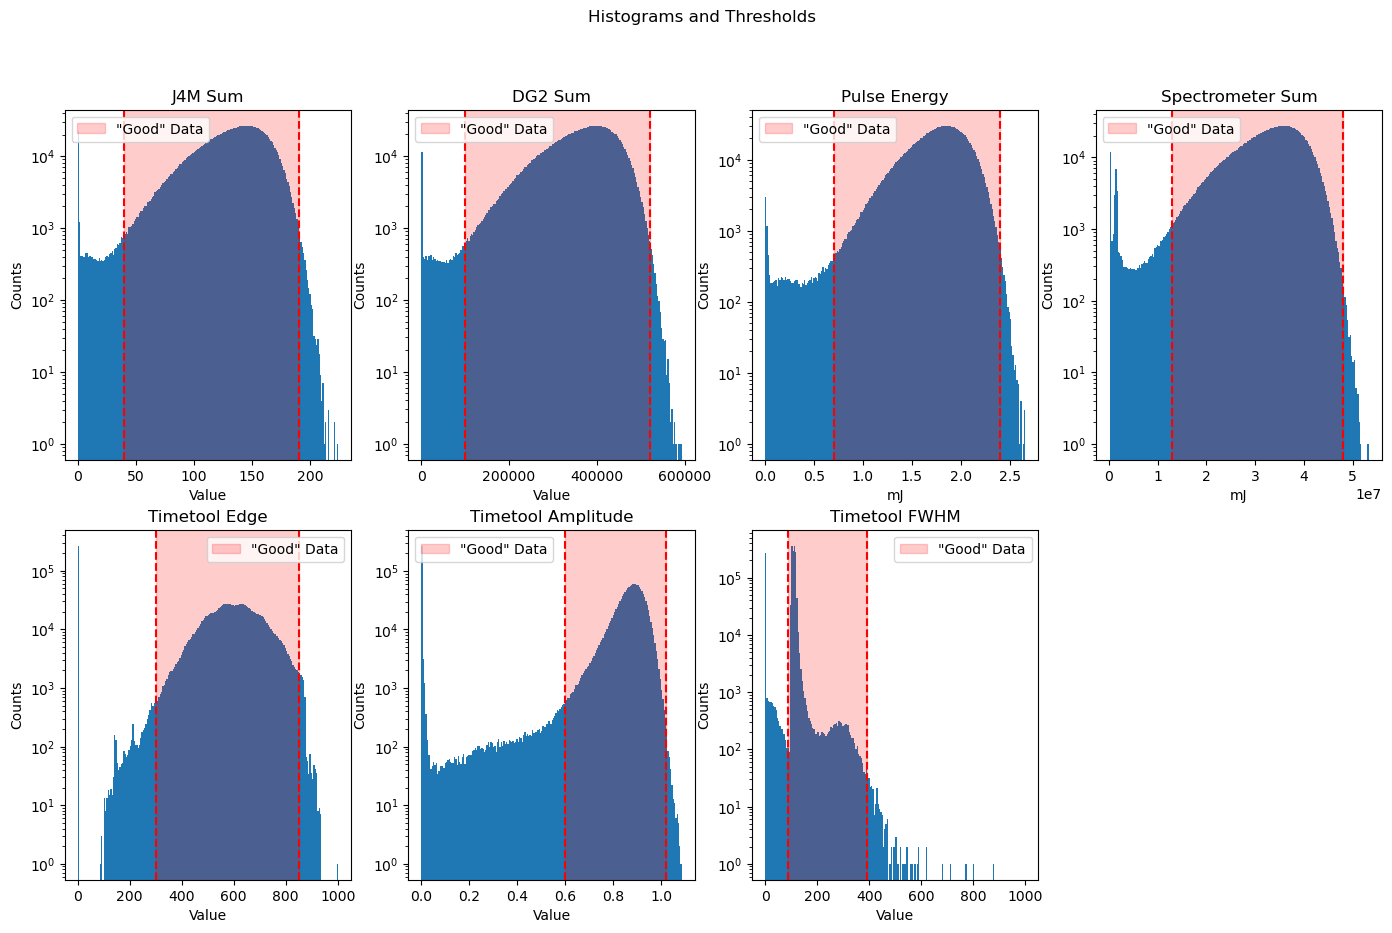

In [19]:
# # Filter cutoffs
################################
# J4M_CUTOFF = [40, 190];
# DG2_CUTOFF = [1e5, 5.2e5];
# PULSE_ENERGY_CUTOFF = [0.7, 2.4] # mJ
# SPEC_CUTOFF = [1.3e7, 4.8e7];
# TT_EDGEPOS_CUTOFF = [300, 850]
# TT_AMP_CUTOFF = [0.6, 1.02]   # mJ     
# TT_WIDTH_CUTOFF = [90, 390]
# FILTER_PLOT_SCALING = 'log' # 'linear'
################################

# Use raw, unnormalized values
_J4MSumSlicedNorm = J4MSumSliced #/np.nanmax(J4MSumSliced);
_I_0Norm = I_0 #/np.nanmax(I_0);
_xray_spectrumNorm = xray_spectrum.sum(axis=1) #/xray_spectrum.sum(axis=1).max();
_ttposSlicedNorm = ttposSliced #/np.nanmax(ttposSliced)
_ttamplSlicedNorm = ttamplSliced #/np.nanmax(ttamplSliced)
_ttfwhmSlicedNorm = ttfwhmSliced #/np.nanmax(ttfwhmSliced)

# Plotting
def plot_filter_threshold_settings(plot_display=FILTER_PLOT_SCALING):
    plt.figure(figsize=[17,10]) 
    def add_subplot(naxis,data,cutoff,title,xlabel='Value',plot_display='log',bins=None):
        plt.subplot(2,4,naxis)
        if bins is None: plt.hist(data,bins=200,range=[0,np.nanmax(data)])
        else: plt.hist(data,bins=bins)
        plt.axvline(cutoff[0],color='r',linestyle='--')
        plt.axvline(cutoff[1],color='r',linestyle='--')
        plt.axvspan(cutoff[0],cutoff[1],color='r',alpha=0.2,label='"Good" Data')
        plt.yscale(plot_display)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel('Counts')
        plt.legend()
        return
    add_subplot(1,_J4MSumSlicedNorm,J4M_CUTOFF,'J4M Sum')
    add_subplot(2,_I_0Norm,DG2_CUTOFF,'DG2 Sum')
    add_subplot(3,pulse_energySliced,PULSE_ENERGY_CUTOFF,'Pulse Energy','mJ')
    add_subplot(4,_xray_spectrumNorm,SPEC_CUTOFF,'Spectrometer Sum','mJ')
    add_subplot(5,_ttposSlicedNorm,TT_EDGEPOS_CUTOFF,'Timetool Edge')
    add_subplot(6,_ttamplSlicedNorm,TT_AMP_CUTOFF,'Timetool Amplitude')
    add_subplot(7,_ttfwhmSlicedNorm,TT_WIDTH_CUTOFF,'Timetool FWHM',bins=np.linspace(0,1000,200))
    plt.suptitle('Histograms and Thresholds')

# Get filtered indices
goodIdx = np.logical_and.reduce([
    xrayOnSliced,
    J4M_CUTOFF[0] <= _J4MSumSlicedNorm,
    _J4MSumSlicedNorm <= J4M_CUTOFF[1],
    DG2_CUTOFF[0] <= _I_0Norm,
    _I_0Norm <= DG2_CUTOFF[1],
    PULSE_ENERGY_CUTOFF[0] <= pulse_energySliced,
    pulse_energySliced <= PULSE_ENERGY_CUTOFF[1],
    SPEC_CUTOFF[0] <= _xray_spectrumNorm,
    _xray_spectrumNorm <= SPEC_CUTOFF[1],
    ~np.isnan(J4MSumSliced)
])
goodIdx_timetool = np.logical_and.reduce([
    TT_EDGEPOS_CUTOFF[0] <= _ttposSlicedNorm,
    _ttposSlicedNorm <= TT_EDGEPOS_CUTOFF[1],
    TT_AMP_CUTOFF[0] <= _ttamplSlicedNorm,
    _ttamplSlicedNorm <= TT_AMP_CUTOFF[1],
    TT_WIDTH_CUTOFF[0] <= _ttfwhmSlicedNorm,
    _ttfwhmSlicedNorm <= TT_WIDTH_CUTOFF[1],
    xrayOnSliced, laserOnSliced
])

# Print & display results
_counts, _ = np.histogram(goodIdx.astype(int),[0,1,2]);
_counts_timetool, _ = np.histogram(goodIdx_timetool.astype(int),[0,1,2]);
print(f'goodIdx data represents {_counts[1]/np.sum(_counts)*100:.2f}% of the total shots. ({_counts[1]} out of {np.sum(_counts)}).')
print(f'goodIdx_timetool data represents {_counts_timetool[1]/np.sum(_counts_timetool)*100:.2f}% of the total shots. ({_counts_timetool[1]} out of {np.sum(_counts_timetool)}).')
plot_filter_threshold_settings()

In [20]:
# # Filter cutoffs
################################
# J4M_CUTOFF = [0.2, 1];
# DG2_CUTOFF = [0.2, 1];
# SPEC_CUTOFF = [0.05, 1];
# PULSE_ENERGY_CUTOFF = [0.5, 2.5] # In mJ!!!
# TT_EDGEPOS_CUTOFF = [0.22, 0.7]     
# TT_AMP_CUTOFF = [0.25, 1]
# TT_WIDTH_CUTOFF = [0.05, 0.25]
# FILTER_PLOT_SCALING = 'log' # 'linear'
################################

# # Determine slice indices based on offset   # @DR: can we move this out of here...?
# if SPECTRUM_OFFSET == -1:
#     _spec_slice = slice(0, -2)
#     _azav_slice = slice(1, -1)
# elif SPECTRUM_OFFSET == 1:
#     _spec_slice = slice(1, -1)
#     azav_slice = slice(0, -2)
# else:  # SPECTRUM_OFFSET == 0 or any default
#     _spec_slice = _azav_slice = slice(None)

# # Apply slices
# xray_spectrum = spec[_spec_slice]
# I_uf = azav_unfiltered[_azav_slice]
# I_f = azav_filtered[_azav_slice]
# J4MSumSliced = J4MSum_unfiltered[_azav_slice]
# J4MSumFilterSliced = J4MSum_filtered[_azav_slice]
# pulse_energySliced = pulse_energy[_azav_slice]
# gasPressureSliced = gasPressure[_azav_slice]
# I_0 = dg2[_azav_slice]
# xrayOnSliced = xrayOn[_azav_slice]
# laserOnSliced = laserOn[_azav_slice]
# ttposSliced = ttpos[_azav_slice]
# ttamplSliced = ttampl[_azav_slice]
# ttfwhmSliced = ttfwhm[_azav_slice]
# scanSliced = scan[_azav_slice]
# run_indicatorSliced = run_indicator[_azav_slice]

# # Precomputing the normalized values
# _J4MSumSlicedNorm = J4MSumSliced/np.nanmax(J4MSumSliced);
# _I_0Norm = I_0/np.nanmax(I_0);
# _xray_spectrumNorm = xray_spectrum.sum(axis=1)/xray_spectrum.sum(axis=1).max();
# _ttposSlicedNorm = ttposSliced/np.nanmax(ttposSliced)
# _ttamplSlicedNorm = ttamplSliced/np.nanmax(ttamplSliced)
# _ttfwhmSlicedNorm = ttfwhmSliced/np.nanmax(ttfwhmSliced)

# # Plotting
# def plot_filter_threshold_settings(plot_display=FILTER_PLOT_SCALING):
#     plt.figure(figsize=[17,10]) 
#     def add_subplot(naxis,data,cutoff,title,xlabel='Fraction of Maximum',plot_display='log',):
#         plt.subplot(2,4,naxis)
#         plt.hist(data,bins=200,range=[0,np.nanmax(data)]);
#         plt.axvline(cutoff[0],color='r',linestyle='--')
#         plt.axvline(cutoff[1],color='r',linestyle='--')
#         plt.axvspan(cutoff[0],cutoff[1],color='r',alpha=0.2,label='"Good" Data')
#         plt.yscale(plot_display)
#         plt.title(title)
#         plt.xlabel(xlabel)
#         plt.ylabel('Counts')
#         plt.legend()
#         return
#     add_subplot(1,_J4MSumSlicedNorm,J4M_CUTOFF,'J4M Sum')
#     add_subplot(2,_I_0Norm,DG2_CUTOFF,'DG2 Sum')
#     add_subplot(3,pulse_energySliced,PULSE_ENERGY_CUTOFF,'Pulse Energy','mJ')
#     add_subplot(4,_xray_spectrumNorm,SPEC_CUTOFF,'Spectrometer Sum','mJ')
#     add_subplot(5,_ttposSlicedNorm,TT_EDGEPOS_CUTOFF,'Timetool Edge')
#     add_subplot(6,_ttamplSlicedNorm,TT_AMP_CUTOFF,'Timetool Amplitude')
#     add_subplot(7,_ttfwhmSlicedNorm,TT_WIDTH_CUTOFF,'Timetool FWHM',)
#     plt.title('Histograms and Thresholds')

# goodIdx = np.logical_and.reduce([
#     xrayOnSliced,
#     J4M_CUTOFF[0] <= _J4MSumSlicedNorm,
#     _J4MSumSlicedNorm <= J4M_CUTOFF[1],
#     DG2_CUTOFF[0] <= _I_0Norm,
#     _I_0Norm <= DG2_CUTOFF[1],
#     PULSE_ENERGY_CUTOFF[0] <= pulse_energySliced,
#     pulse_energySliced <= PULSE_ENERGY_CUTOFF[1],
#     SPEC_CUTOFF[0] <= _xray_spectrumNorm,
#     _xray_spectrumNorm <= SPEC_CUTOFF[1],
#     ~np.isnan(J4MSumSliced)
# ])

# goodIdx_timetool = np.logical_and.reduce([
#     TT_EDGEPOS_CUTOFF[0] <= _ttposSlicedNorm,
#     _ttposSlicedNorm <= TT_EDGEPOS_CUTOFF[1],
#     TT_AMP_CUTOFF[0] <= _ttamplSlicedNorm,
#     _ttamplSlicedNorm <= TT_AMP_CUTOFF[1],
#     TT_WIDTH_CUTOFF[0] <= _ttfwhmSlicedNorm,
#     _ttfwhmSlicedNorm <= TT_WIDTH_CUTOFF[1],
#     xrayOnSliced, laserOnSliced
# ])

# # Displaying how much data was kept due to this filtering
# _counts, _ = np.histogram(goodIdx.astype(int),[0,1,2]);
# _counts_timetool, _ = np.histogram(goodIdx_timetool.astype(int),[0,1,2]);
# print(f'goodIdx data represents {_counts[1]/np.sum(_counts)*100:.2f}% of the total shots. ({_counts[1]} out of {np.sum(_counts)}).')
# print(f'goodIdx_timetool data represents {_counts_timetool[1]/np.sum(_counts_timetool)*100:.2f}% of the total shots. ({_counts_timetool[1]} out of {np.sum(_counts_timetool)}).')

# # Plot
# plot_filter_threshold_settings()

In [22]:
# Get spectrometer calibration
_coefficients = xrst.get_config_for_runs(int(runNumbers[0]),'spectrometer_calibration','coefficients')
_poly = np.poly1d(_coefficients)
xray_spectrum_range = _poly(np.arange(len(spec[0])))
# xray_spectrum_range = np.load('15-28.npy')*1000 # Temp
print(_coefficients)

[7e-05, 9.594565]


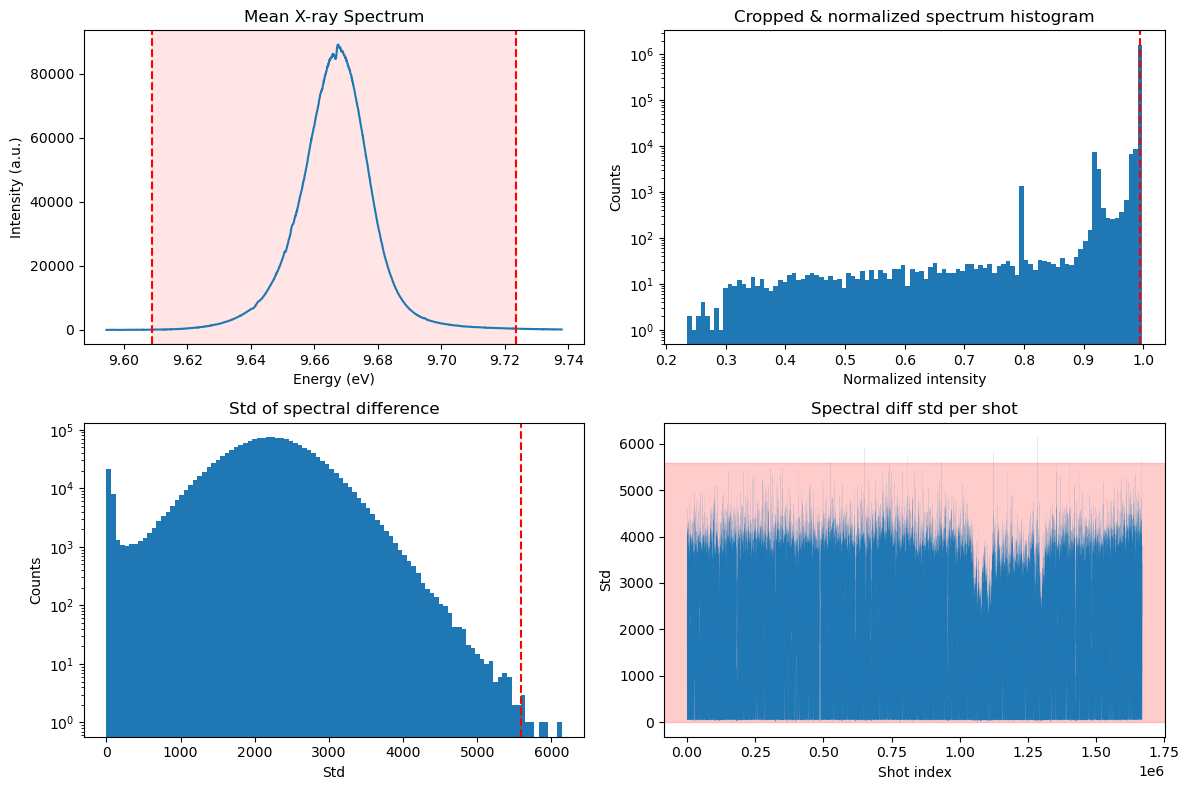

Fraction of good data after spectrometer filtering: 0.9785


In [23]:
# Additional spectral filtering

################################
# SPECTRUM_CROP_FACTOR = 0.8
# SPECTRUM_FRACTION_INSIDE = 0.995
# SPECTRUM_PLOT_FILTER = True
################################

# fraction of the spectrum to keep
_cropin = round((1 - SPECTRUM_CROP_FACTOR) / 2 * xray_spectrum.shape[1])
_cropped_sum_norm = (
    xray_spectrum[:, _cropin : xray_spectrum.shape[1] - _cropin].sum(axis=1)
    / xray_spectrum.sum(axis=1)
)
_mask_spec_crop = _cropped_sum_norm > SPECTRUM_FRACTION_INSIDE
_spec_diff_std = np.std(np.diff(xray_spectrum, axis=1), axis=1)
_spec_cutoff = (_spec_diff_std.mean() + _spec_diff_std.std()) * 2    # n.b. - distinct from SPEC_CUTOFF
_mask_noise = _spec_diff_std <= _spec_cutoff
# _mask_noise = _spec_diff_std <= 1500

if SPECTRUM_PLOT_FILTER:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax = axes[0, 0]
    ax.plot(xray_spectrum_range, xray_spectrum.mean(axis=0))
    ax.axvline(xray_spectrum_range[_cropin], color="r", ls="--", label="Crop limit")
    ax.axvline(xray_spectrum_range[-_cropin - 1], color="r", ls="--")
    ax.axvspan(xray_spectrum_range[_cropin], xray_spectrum_range[-_cropin - 1],alpha=0.1, color="r")
    ax.set(title="Mean X-ray Spectrum", xlabel="Energy (eV)", ylabel="Intensity (a.u.)")
    ax = axes[0, 1]
    ax.hist(_cropped_sum_norm, bins=100)
    ax.set_yscale("log")
    ax.axvline(SPECTRUM_FRACTION_INSIDE, color="r", ls="--", label="Threshold")
    ax.set(title="Cropped & normalized spectrum histogram",xlabel="Normalized intensity", ylabel="Counts")
    ax = axes[1, 0]
    ax.hist(_spec_diff_std, bins=100)
    ax.set_yscale("log")
    ax.axvline(_spec_cutoff, color="r", ls="--")
    ax.set(title="Std of spectral difference", xlabel="Std", ylabel="Counts")
    ax = axes[1, 1]
    ax.plot(_spec_diff_std,linewidth=0.05)
    ax.axhspan(0,_spec_cutoff, color="r",alpha=0.2)
    ax.set(title="Spectral diff std per shot", xlabel="Shot index", ylabel="Std")
    plt.tight_layout()
    plt.show()

mask_spectrum = _mask_spec_crop
print(f"Fraction of good data after spectrometer filtering: "
      f"{mask_spectrum.sum() / mask_spectrum.size:.4f}")

## Timetool correction / rebinning if necessary

In [24]:
time_bins_raw

array([-2.3, -2.1, -1.7, -1.5, -1.3, -0.8, -0.6,  4.2,  4.4])

In [94]:
# Time binning params

# ################################
# TIME_BIN_EDGES = [-3,-2,-1.1,0,5]
# TT_CORRECTION = True
# TT_PLOT = True
# ################################

# set time bins
time_bin_centers_raw = [
    time_bins_raw[0],
    np.mean(time_bins_raw[2:4]),
    time_bins_raw[5],
    time_bins_raw[7],
]
# set time bin colors
tcmap = colormaps.get_cmap('cool')
tcolors = [tcmap(x) for x in np.linspace(0,1,len(time_bin_centers_raw))]

print(time_bin_centers_raw)

[-2.3000000011434554, -1.6000000002982757, -0.8000000003608961, 4.1999999991418475]


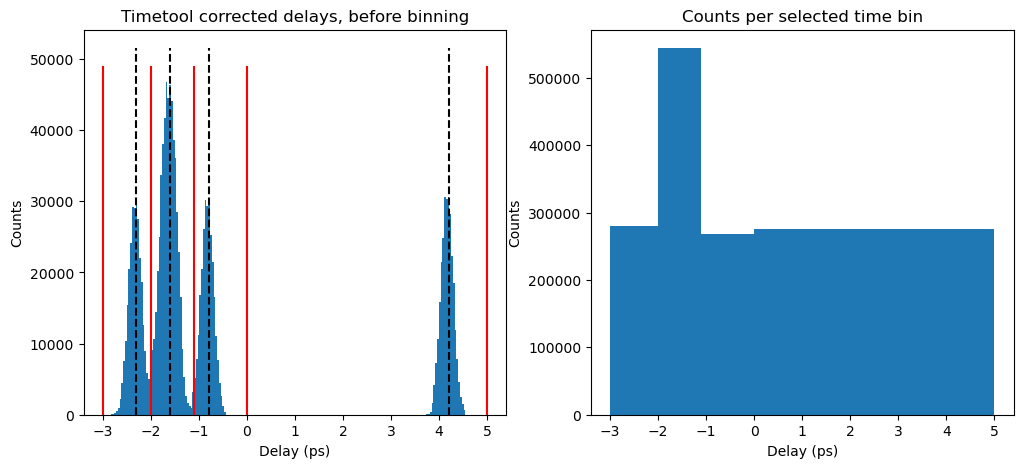

In [96]:
# Use the data in config.yaml or set your own, these should be in seconds, and can be scalar, sequence or ndarray
_tt_slopes = xrst.get_config_for_runs(runNumbers,'tt_calibration','slope')
_tt_intercepts = xrst.get_config_for_runs(runNumbers,'tt_calibration','intercept')

# Select bins, in ps
if TT_CORRECTION and len(TIME_BIN_EDGES)!=0:
    time_bins_selected = TIME_BIN_EDGES
else:
    # Default to the time bins that were recorded
    time_bins_selected = time_bins_raw

# Timetool correction on a run by run basis
if TT_CORRECTION:
    time_delay = xrst.calib.apply_timetool_correction(
        delays = scanSliced,
        edge_positions = ttposSliced,
        slopes = _tt_slopes,
        intercepts = _tt_intercepts,
        run_indicator = run_indicatorSliced # Optional, if None, only one timetool calibration applied to all shots.
    )
    if TT_PLOT:
        plt.figure(figsize=[12,5])
        plt.subplot(1,2,1)
        plt.hist(time_delay[goodIdx_timetool]*10**12,bins=200)
        plt.xlabel('Delay (ps)')
        plt.title('Timetool corrected delays, before binning')
        plt.ylabel('Counts')
        plt.vlines(time_bins_selected,0,plt.ylim()[1],color='r')
        # plt.vlines(time_bins_raw,0,plt.ylim()[1],color='k',ls='--')
        plt.vlines(time_bin_centers_raw,0,plt.ylim()[1],color='k',ls='--')
        plt.subplot(1,2,2)
else:
    time_delay = scan
    
# Convert to ps & determine bin idx for each shot
binned_shot_idxs = np.digitize(time_delay*10**12,time_bins_selected)

if TT_PLOT:
    plt.hist(time_delay[goodIdx_timetool]*10**12,bins=time_bins_selected)
    plt.xlabel('Delay (ps)')
    plt.title('Counts per selected time bin')
    plt.ylabel('Counts')
# plt.suptitle(niceTitle)
plt.show()

### Determine final shot masks

In [32]:
# Filter by time

if TT_CORRECTION:
    # goodIdx_timetool already includes laserOn shots
    on_mask =  goodIdx & goodIdx_timetool & mask_spectrum
else:
    # Just the good shots where the laser is on
    on_mask = goodIdx & laserOnSliced & mask_spectrum
# Timetool isn't needed for the off shots
off_mask = goodIdx & ~laserOnSliced & mask_spectrum

# Displaying how much data was kept due to this filtering
_counts, _ = np.histogram(on_mask.astype(int),[0,1,2]);
print(f'Combined filters retained {_counts[1]/np.sum(laserOnSliced)*100:.2f}% of the laser on shots. ({_counts[1]} out of {np.sum(laserOnSliced)}).')
_counts, _ = np.histogram(off_mask.astype(int),[0,1,2]);
print(f'Combined filters retained {_counts[1]/np.sum(~laserOnSliced)*100:.2f}% of the laser off shots. ({_counts[1]} out of {np.sum(~laserOnSliced)}).')

Combined filters retained 89.47% of the laser on shots. (1279723 out of 1430284).
Combined filters retained 91.18% of the laser off shots. (217362 out of 238382).


In [38]:
# Setup time bins

################################
T0 = -1.6   # @DR: where is this T0 now coming from? why is it set here?
################################

# set bin centers and labels with T0
time_bin_centers = np.array(time_bin_centers_raw) - T0
time_bin_labels = [f"{x:.1f} ps" for x in time_bin_centers]
# labels with 'off' group
time_bin_centers_withoff = [np.nan]+time_bin_centers
time_bin_labels_withoff = ['off']+time_bin_labels

In [39]:
time_bin_labels

['-0.7 ps', '-0.0 ps', '0.8 ps', '5.8 ps']

In [40]:
# Apply the union of on/off masks to select all analyzable shots
_all_good = on_mask | off_mask

gasPressure_m   = gasPressureSliced[_all_good]
xray_spectrum_m = xray_spectrum[_all_good]
I_f_m           = I_f[_all_good]
I_uf_m          = I_uf[_all_good]
I_0_m           = I_0[_all_good]
I_ratio         = I_f_m / I_uf_m

# Track laser status and time bin index within the masked set
is_on_m        = on_mask[_all_good]
is_off_m       = off_mask[_all_good]
time_bin_idx_m = binned_shot_idxs[_all_good]

# Prepare list of time bin masks
_unique_on_bins = np.sort(np.unique(time_bin_idx_m[is_on_m]))
time_group_masks = [is_off_m]+[is_on_m & (time_bin_idx_m == _b) for _b in _unique_on_bins]
n_time_groups = len(time_group_masks)

# Print results
print(f"{'Group':<15} {'Shots':>8}")
print("-" * 25)
for _lbl, _m in zip(time_bin_labels_withoff, time_group_masks):
    print(f"  {_lbl:<13} {np.sum(_m):>6}")
print(f"\nTotal time groups: {n_time_groups}")

Group              Shots
-------------------------
  off           217362
  -0.7 ps       262033
  -0.0 ps       509818
  0.8 ps        250903
  5.8 ps        256969

Total time groups: 5


/lscratch/bsavitzk/tmp/ipykernel_2869587/2710208527.py:9: RuntimeWarning: divide by zero encountered in divide
  I_ratio         = I_f_m / I_uf_m
/lscratch/bsavitzk/tmp/ipykernel_2869587/2710208527.py:9: RuntimeWarning: invalid value encountered in divide
  I_ratio         = I_f_m / I_uf_m



## Preprocessing for ghost imaging


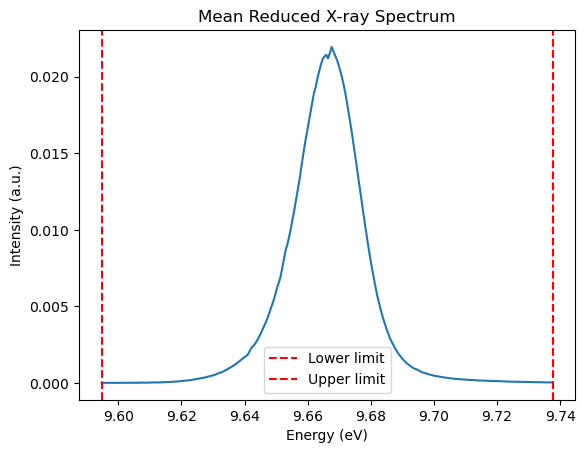

In [41]:
# Downsample energy

################################
# SPECTRUM_N_REBIN = 8
# SPECTRUM_CROP_REBIN = (0, 256)
# SPECTRUM_PLOT_REBIN = True
################################

_n_shots, _n_spec = xray_spectrum_m.shape
_n_bins = _n_spec // SPECTRUM_N_REBIN

# Rebin by averaging groups of SPECTRUM_N_REBIN consecutive channels
_xray_spec_reduced = xray_spectrum_m.reshape(_n_shots, _n_bins, SPECTRUM_N_REBIN).mean(axis=2)
_idx_centers = np.floor(np.arange(_n_spec).reshape(_n_bins, SPECTRUM_N_REBIN).mean(axis=1)).astype(int)
xray_range_reduced = xray_spectrum_range[_idx_centers]

# Normalize each shot's spectrum to unit integral
xray_spec_norm = _xray_spec_reduced / _xray_spec_reduced.sum(axis=1, keepdims=True)

if SPECTRUM_PLOT_REBIN:
    fig, ax = plt.subplots()
    ax.plot(xray_range_reduced, xray_spec_norm.mean(axis=0))
    ax.axvline(xray_range_reduced[SPECTRUM_CROP_REBIN[0]], color="r", ls="--", label="Lower limit")
    ax.axvline(xray_range_reduced[SPECTRUM_CROP_REBIN[1] - 1], color="r", ls="--", label="Upper limit")
    ax.set(title="Mean Reduced X-ray Spectrum", xlabel="Energy (eV)", ylabel="Intensity (a.u.)")
    ax.legend()
    plt.show()

### This cell won't really do anything because the fluorescence correction has to be done in post, and we don't have time for it. For now I artifically set the fluorescence correction array to all one so it doesn't modify the signal anymore.

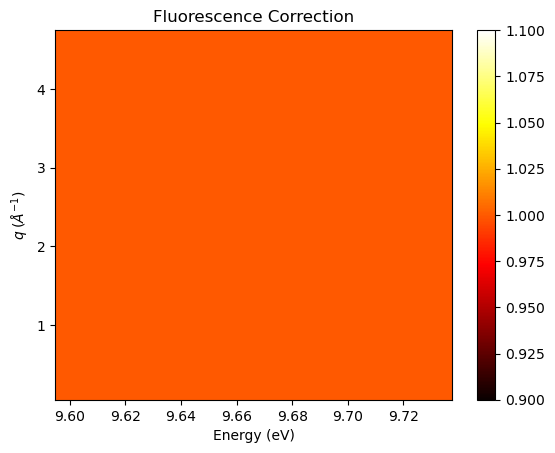

/lscratch/bsavitzk/tmp/ipykernel_2869587/740142671.py:39: RuntimeWarning: Mean of empty slice
  I_tot[:, _t]     = np.nanmean(_norm, axis=0)
/sdf/group/lcls/ds/tools/conda_envs/weber_group/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


I_tot shape: (48, 5)  →  (q, time_groups)


In [42]:
# fl_struct = sio.loadmat("F_Correction_9666.mat", squeeze_me=True)
_fl_q       = q  # np.asarray(fl_struct["q"], dtype=np.float64)
_flu_f_corr  = np.ones_like(_fl_q)  # np.asarray(fl_struct["flu_f_corr"], dtype=np.float64)
_flu_uf_corr = np.ones_like(_fl_q)  # np.asarray(fl_struct["flu_uf_corr"], dtype=np.float64)
_above_ratio = _flu_f_corr / _flu_uf_corr

# Build fluorescence correction matrices — vectorised
_above_mask = xray_range_reduced > 9664  # bool array (n_bins,)

_ZnFlu    = np.ones((len(xray_range_reduced), len(q)))
_ZnFlu_uf = np.ones((len(xray_range_reduced), len(q)))

_above_ratio_interp = np.interp(q, _fl_q, _above_ratio)
_flu_uf_interp      = np.interp(q, _fl_q, _flu_uf_corr)

_ZnFlu[_above_mask, :]    = _above_ratio_interp[None, :]
_ZnFlu_uf[_above_mask, :] = _flu_uf_interp[None, :]

# --- Plot ---
fig, ax = plt.subplots()
_im = ax.imshow(
    _ZnFlu.T, aspect="auto", origin="lower", cmap="hot",
    extent=[xray_range_reduced[0], xray_range_reduced[-1], q[0], q[-1]],
)
ax.set(xlabel="Energy (eV)", ylabel=r"$q\;(\AA^{-1})$", title="Fluorescence Correction")
plt.colorbar(_im, ax=ax)
plt.show()

# Apply fluorescence correction to all shots
_shot_flu_corr    = xray_spec_norm @ _ZnFlu       # (n_shots, n_q)
_shot_uf_flu_corr = xray_spec_norm @ _ZnFlu_uf    # (n_shots, n_q)
I_ratio_corrected = I_ratio * _shot_flu_corr

# Compute I_tot per time group
I_tot     = np.zeros((len(q), n_time_groups))
I_tot_std = np.zeros((len(q), n_time_groups))
for _t, _m in enumerate(time_group_masks):
    _norm = I_uf_m[_m] / (I_0_m[_m, None] * gasPressure_m[_m, None]) * _shot_uf_flu_corr[_m]
    I_tot[:, _t]     = np.nanmean(_norm, axis=0)
    I_tot_std[:, _t] = np.nanstd(_norm, axis=0)

print(f"I_tot shape: {I_tot.shape}  →  (q, time_groups)")



## Time-dependent ghost imaging analysis
Compute A-vectors, filter function, and deconvolved scattering spectrum for each time group (off + each laser-on delay bin).


/lscratch/bsavitzk/tmp/ipykernel_2869587/3199694197.py:21: RuntimeWarning: invalid value encountered in matmul
  _XtY = _X.T @ _Y


A shape: (256, 48, 5)  →  (energy, q, time_groups)


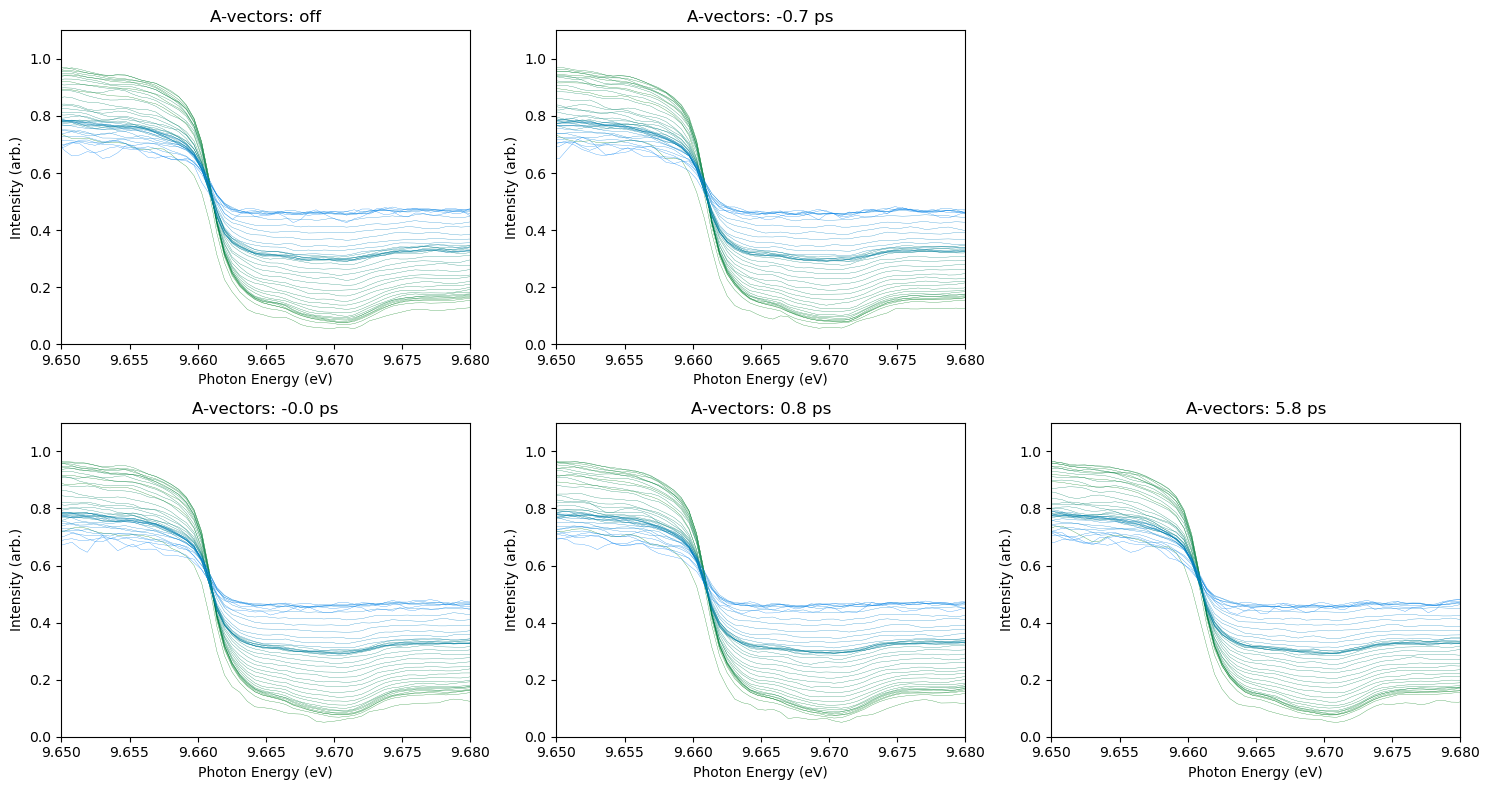

In [43]:
################################
# GI_LAMBDA = 3
# GI_PLOT_A = True
# GI_E_MIN, GI_E_MAX = 9.65, 9.68
################################

_X_all = xray_spec_norm[:, SPECTRUM_CROP_REBIN[0]:SPECTRUM_CROP_REBIN[1]]   # (n_shots, n_features)
_Y_all = I_ratio_corrected                                      # (n_shots, n_q)
_n_features = _X_all.shape[1]

# 2nd-derivative penalty matrix (shared across time groups)
_D2 = np.diff(np.eye(_n_features), n=2, axis=0)  # (n_features-2, n_features)
_R  = _D2.T @ _D2                                 # (n_features, n_features)

# Compute A for each time group
A = np.zeros((_n_features, len(q), n_time_groups))
for _t, _m in enumerate(time_group_masks):
    _X = _X_all[_m]
    _Y = _Y_all[_m]
    _XtX = _X.T @ _X
    _XtY = _X.T @ _Y
    A[:, :, _t] = np.linalg.solve(_XtX + GI_LAMBDA * _R, _XtY)

print(f"A shape: {A.shape}  →  (energy, q, time_groups)")

if GI_PLOT_A:
    _E_crop = xray_range_reduced[SPECTRUM_CROP_REBIN[0]:SPECTRUM_CROP_REBIN[1]]
    _ncols = min(n_time_groups, 3)
    _nrows = int(np.ceil(n_time_groups / _ncols))
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False)
    for _t in range(n_time_groups):
        __t = _t if _t<=1 else _t+1
        _ax = axes[__t // _ncols, __t % _ncols]
        for _qi in range(A.shape[1]):
            _c = (0, 0.5, _qi / A.shape[1])
            _ax.plot(_E_crop, A[:, _qi, _t], lw=0.2, color=_c)
        _ax.set(xlim=[GI_E_MIN, GI_E_MAX],ylim=[0,1.1],
                # title=f"A-vectors: {delay_labels[_t]}",
                title=f"A-vectors: {time_bin_labels_withoff[_t]}",
                xlabel="Photon Energy (eV)", ylabel="Intensity (arb.)")
    axes[0,2].set_visible(False)
    # for _i in range(n_time_groups, _nrows * _ncols):
    #     axes[_i // _ncols, _i % _ncols].set_visible(False)
    plt.tight_layout()
    plt.show()


### Determine the filter function from the laser-off reference
The Zn foil filter function is derived from the laser-off A-vectors (ground state) and applied uniformly to all time groups during deconvolution.


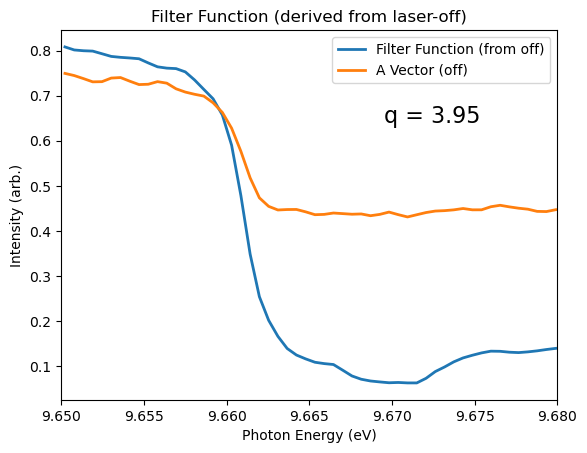

In [65]:
################################
# GI_PLOT_FILTER = True
################################

_mask_e   = (xray_range_reduced >= GI_E_MIN) & (xray_range_reduced < GI_E_MAX)
_mask_e_crop = _mask_e[SPECTRUM_CROP_REBIN[0]:SPECTRUM_CROP_REBIN[1]]

# Energy-crop A for all time groups
A_short  = A[_mask_e_crop, :, :]   # (N_short, n_q, n_time_groups)
A_short  = np.nan_to_num(A_short, nan=0.0, posinf=0.0, neginf=0.0)

E_pix    = xray_range_reduced[_mask_e]
N_short  = len(E_pix)

# wavelength = xrst.keV2Angstroms(np.mean(photon_energy))  # Å       ### Failing - unclear why
wavelength = 0.0012809893340891096                                   ### Using value from shift 1
twotheta = 2 * np.arcsin(q * wavelength / (4 * np.pi))

# Reference range (low-q)  — MATLAB indices 17:19 → Python 16:19
QLOW1, QLOW2 = 4, 6  # 0-based, slice is [16:19]

# Derive filter function from laser-OFF A-vectors (time group index 0)
_A_off_ref = np.clip(A_short[:, QLOW1:QLOW2, 0], a_min=1e-30, a_max=None)
_mut = np.mean(-np.log(_A_off_ref) * np.cos(twotheta[QLOW1:QLOW2]), axis=1)
f_q = np.real(np.exp(-_mut[:, None] / np.cos(twotheta[None, :])))
f_q = np.nan_to_num(f_q, nan=0.0, posinf=0.0, neginf=0.0)

QVALUE = 39  # 0-based index for plotting

if GI_PLOT_FILTER:
    fig, ax = plt.subplots()
    ax.plot(E_pix, f_q[:, QVALUE], lw=2, label="Filter Function (from off)")
    ax.plot(E_pix, A_short[:, QVALUE, 0], lw=2, label="A Vector (off)")
    ax.set(xlim=(GI_E_MIN, GI_E_MAX), title="Filter Function (derived from laser-off)",
           xlabel="Photon Energy (eV)", ylabel="Intensity (arb.)")
    ax.text(0.65, 0.75, f"q = {q[QVALUE]:.2f}", transform=ax.transAxes, fontsize=16)
    ax.legend()
    plt.show()


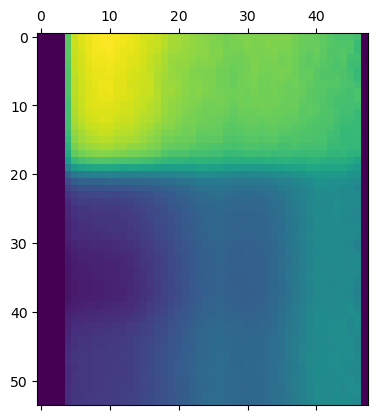

In [53]:
plt.matshow(A_short[:,:,0])


### Deconvolve scattering spectrum for each time group
Produces `S_spec` with shape `(energy, q, time_groups)` where index 0 is laser-off.


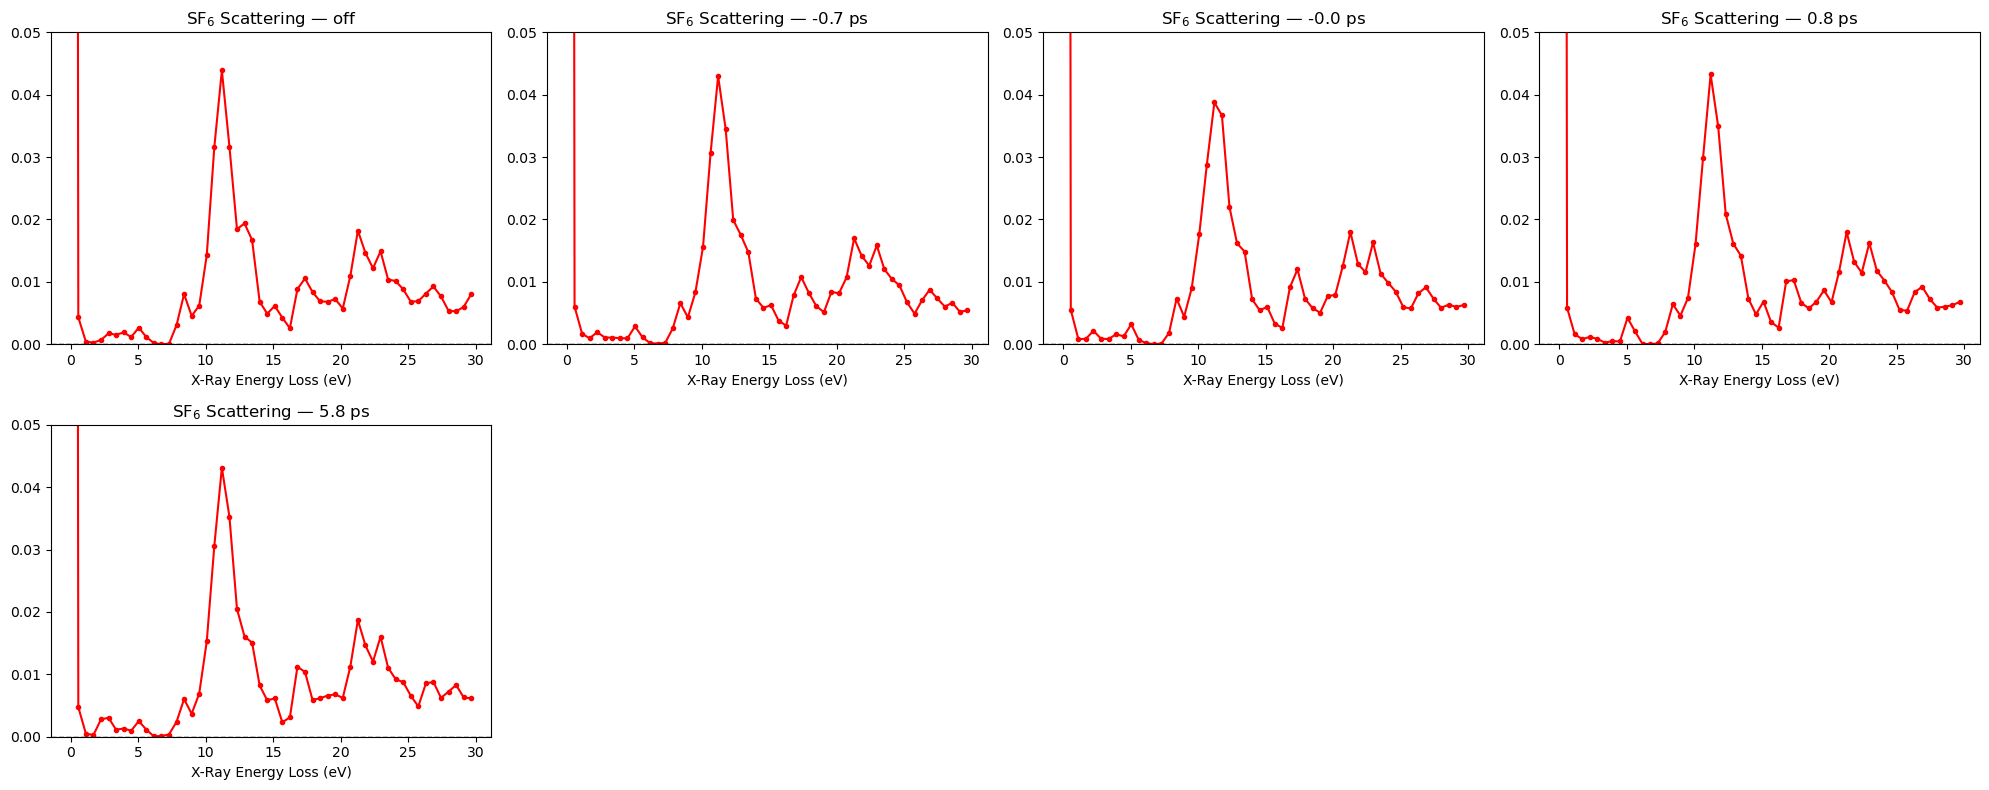

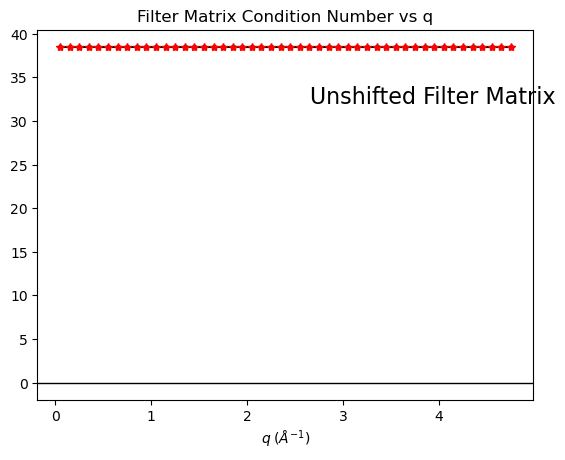

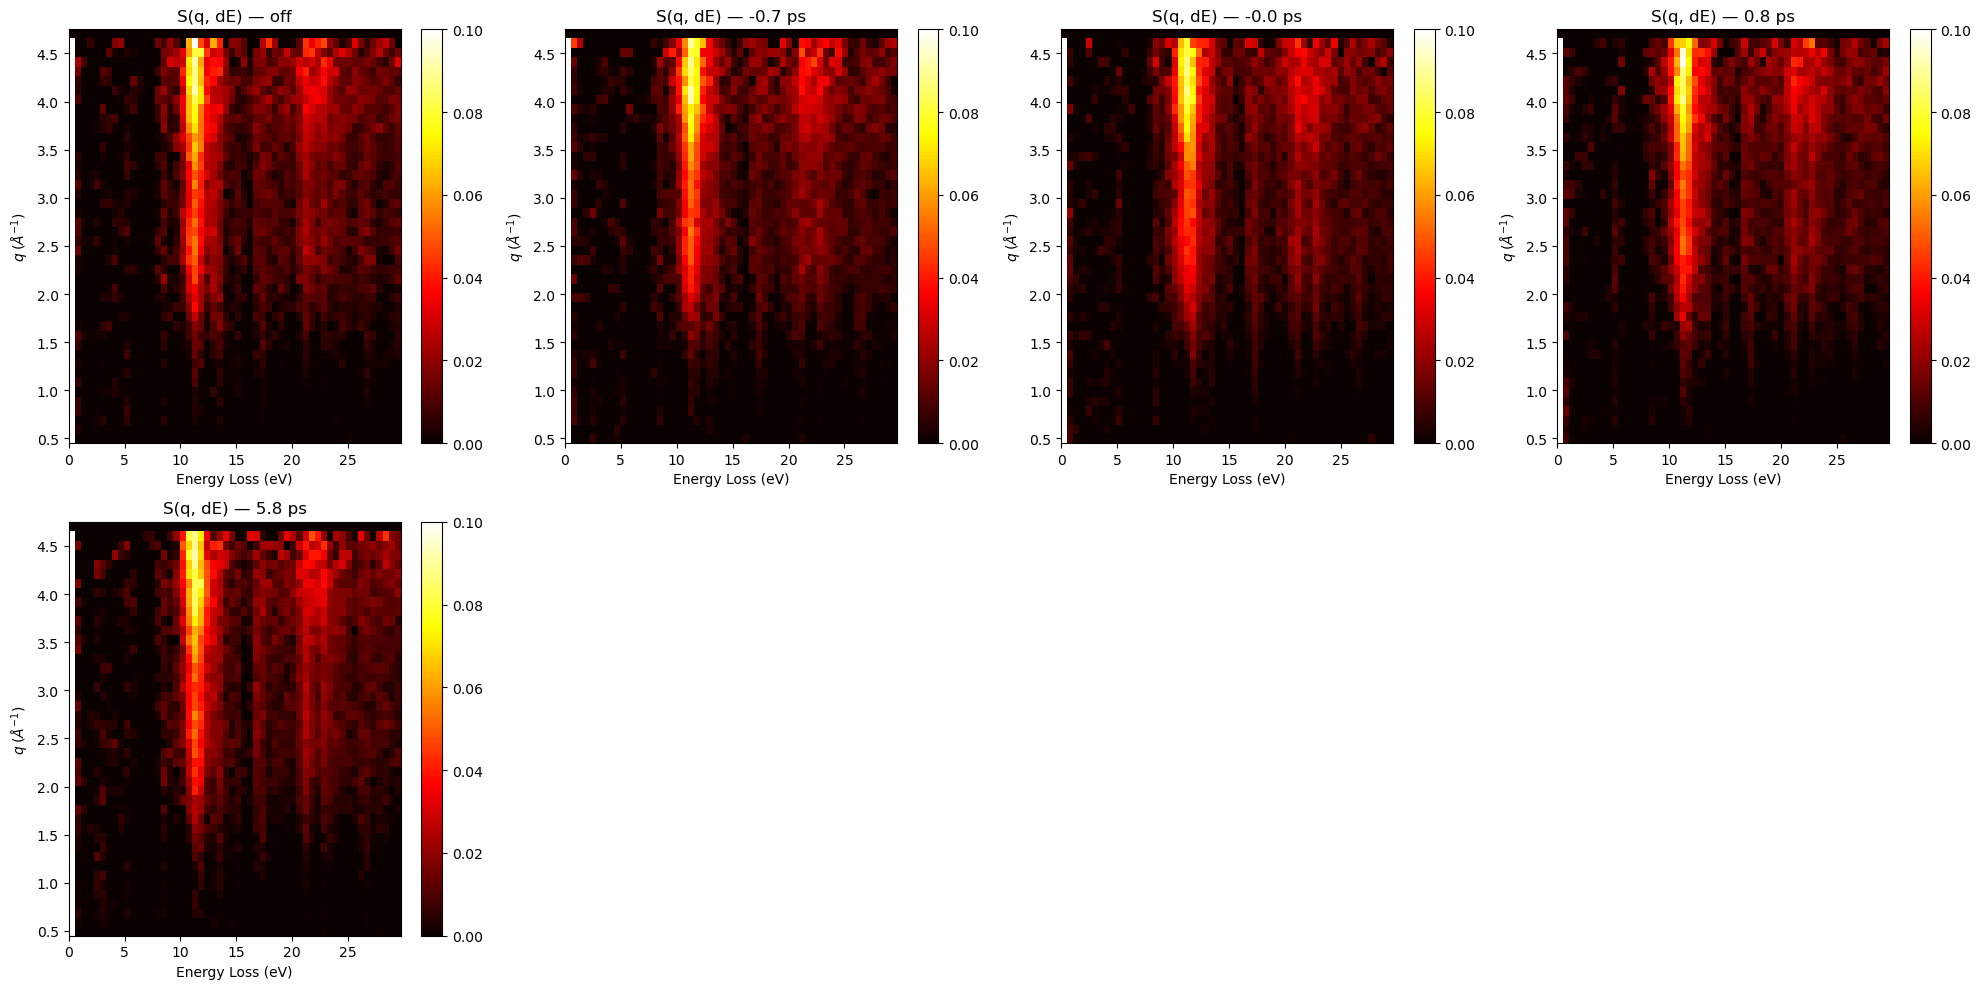

S_spec shape: (54, 48, 5)  →  (energy, q, time_groups)
Time groups: ['off', '-0.7 ps', '-0.0 ps', '0.8 ps', '5.8 ps']


In [66]:
################################
# GI_PLOT_SCATTER = True
################################

CondN  = np.zeros(len(q))
S_spec = np.zeros((N_short, len(q), n_time_groups))

for _t in range(n_time_groups):
    for _qi in range(len(q)):
        # Build Toeplitz filter matrix
        _col = np.zeros(N_short)
        _col[0] = f_q[0, _qi]
        _row = f_q[:, _qi]
        _F_Zn = toeplitz(_col, _row).T

        if _t == 0:
            CondN[_qi] = np.linalg.cond(_F_Zn)
        S_spec[:, _qi, _t], _ = nnls(_F_Zn, A_short[:, _qi, _t])

if GI_PLOT_SCATTER:
    _E_loss = (E_pix - E_pix[0]) * 1000
    _ncols = min(n_time_groups, 4)
    _nrows = int(np.ceil(n_time_groups / _ncols))

    # Average scattering spectrum per time group
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False)
    for _t in range(n_time_groups):
        _ax = axes[_t // _ncols, _t % _ncols]
        _ax.plot(_E_loss, S_spec[:, 4:, _t].mean(axis=1), "r.-")
        _ax.axhline(0, color="k", ls="--", lw=1)
        _ax.set(title=f"SF$_6$ Scattering — {time_bin_labels_withoff[_t]}",
                xlabel="X-Ray Energy Loss (eV)")
        _ax.set_ylim(0,0.05)
    for _i in range(n_time_groups, _nrows * _ncols):
        axes[_i // _ncols, _i % _ncols].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Condition number vs q (same filter for all groups)
    fig, ax = plt.subplots()
    ax.plot(q, CondN, "k.-")
    ax.plot(q, CondN, "r*")
    ax.axhline(0, color="k", lw=1)
    ax.set(title="Filter Matrix Condition Number vs q",
           xlabel=r"$q\;(\AA^{-1})$")
    ax.text(0.55, 0.8, "Unshifted Filter Matrix", transform=ax.transAxes, fontsize=16)
    plt.show()

    # 2-D colour map S(q, dE) per time group
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 5 * _nrows), squeeze=False)
    for _t in range(n_time_groups):
        _ax = axes[_t // _ncols, _t % _ncols]
        _im = _ax.imshow(
            S_spec[:, :, _t].T, aspect="auto", origin="lower", cmap="hot",
            extent=[_E_loss[0], _E_loss[-1], q[0], q[-1]],
            vmin=0, vmax=0.1,
        )
        # _ax.set_ylim(q[14], q[-1])
        _ax.set_ylim(q[4], q[-1])
        _ax.set(xlabel="Energy Loss (eV)", ylabel=r"$q\;(\AA^{-1})$",
                title=f"S(q, dE) — {time_bin_labels_withoff[_t]}")
        plt.colorbar(_im, ax=_ax)
    for _i in range(n_time_groups, _nrows * _ncols):
        axes[_i // _ncols, _i % _ncols].set_visible(False)
    plt.tight_layout()
    plt.show()

print(f"S_spec shape: {S_spec.shape}  →  (energy, q, time_groups)")
print(f"Time groups: {time_bin_labels_withoff}")


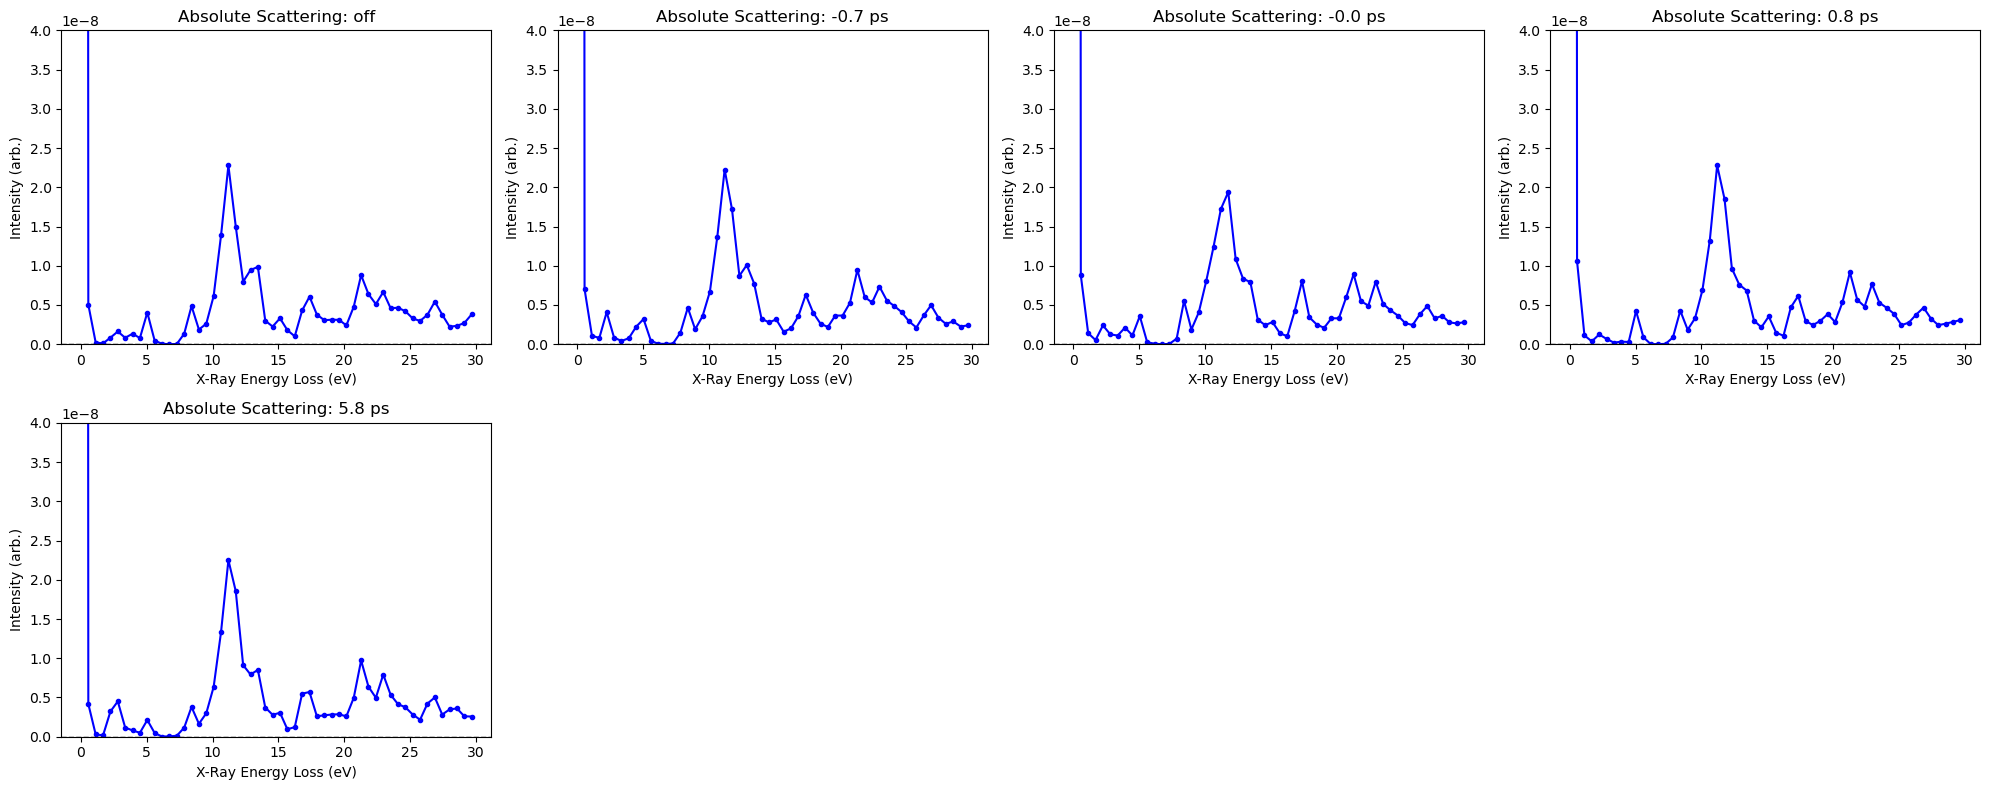

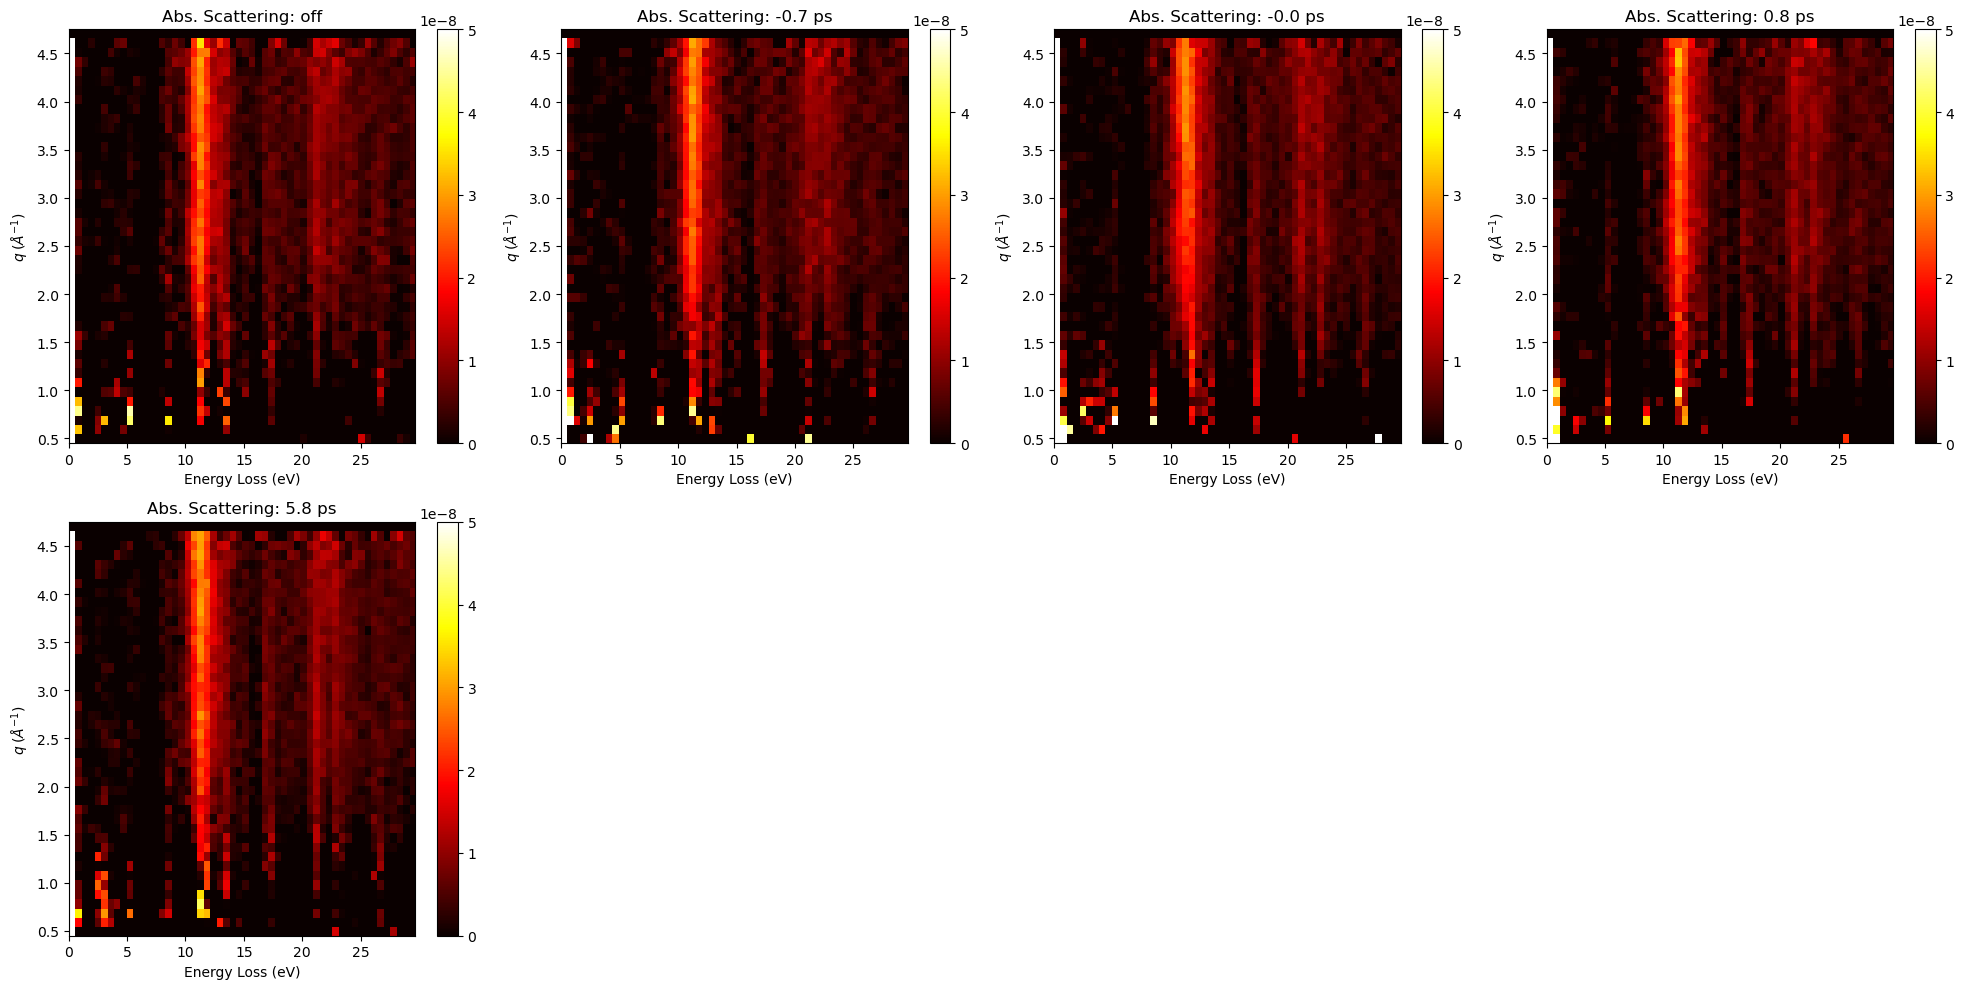

S_spec_abs shape: (54, 48, 5)  →  (energy, q, time_groups)


In [67]:
# ################################
# GI_PLOT_ABS = True
# GI_VMAX_ABS = 0.5e-7  # set to a float to fix the colour scale, None for auto
# ################################

# S_spec : (energy, q, time_groups)  — normalised (total = 1)
# I_tot  : (q, time_groups)          — absolute total scattering per q per time group
# Broadcast I_tot across the energy axis to recover absolute scattering
S_spec_abs = S_spec * I_tot[None, :, :]   # (energy, q, time_groups)

if GI_PLOT_ABS:
    _E_loss = (E_pix - E_pix[0])*1000
    _ncols = min(n_time_groups, 4)
    _nrows = int(np.ceil(n_time_groups / _ncols))

    # --- 1D: q-averaged absolute scattering spectrum per time group ---
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 4 * _nrows), squeeze=False)
    for _t in range(n_time_groups):
        _ax = axes[_t // _ncols, _t % _ncols]
        _ax.plot(_E_loss, S_spec_abs[:, 4:, _t].mean(axis=1), "b.-")
        _ax.axhline(0, color="k", ls="--", lw=1)
        _ax.set(ylim = [0,0.4e-7],
            title=f"Absolute Scattering: {time_bin_labels_withoff[_t]}",
            xlabel="X-Ray Energy Loss (eV)", ylabel="Intensity (arb.)")
    for _i in range(n_time_groups, _nrows * _ncols):
        axes[_i // _ncols, _i % _ncols].set_visible(False)
    plt.tight_layout()
    plt.show()

    # --- 2D colour maps: S_abs(q, dE) per time group ---
    _vmax = GI_VMAX_ABS if GI_VMAX_ABS is not None else np.nanpercentile(S_spec_abs[:, 4:, :], 99)
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(5 * _ncols, 5 * _nrows), squeeze=False)
    for _t in range(n_time_groups):
        _ax = axes[_t // _ncols, _t % _ncols]
        _im = _ax.imshow(
            S_spec_abs[:, :, _t].T, aspect="auto", origin="lower", cmap="hot",
            extent=[_E_loss[0], _E_loss[-1], q[0], q[-1]],
            vmin=0, vmax=_vmax,
        )
        # _ax.set_ylim(q[14], q[-1])
        _ax.set_ylim(q[4], q[-1])
        _ax.set(xlabel="Energy Loss (eV)", ylabel=r"$q\;(\AA^{-1})$",
                title=f"Abs. Scattering: {time_bin_labels_withoff[_t]}")
        plt.colorbar(_im, ax=_ax)
    for _i in range(n_time_groups, _nrows * _ncols):
        axes[_i // _ncols, _i % _ncols].set_visible(False)
    plt.tight_layout()
    plt.show()

print(f"S_spec_abs shape: {S_spec_abs.shape}  →  (energy, q, time_groups)")


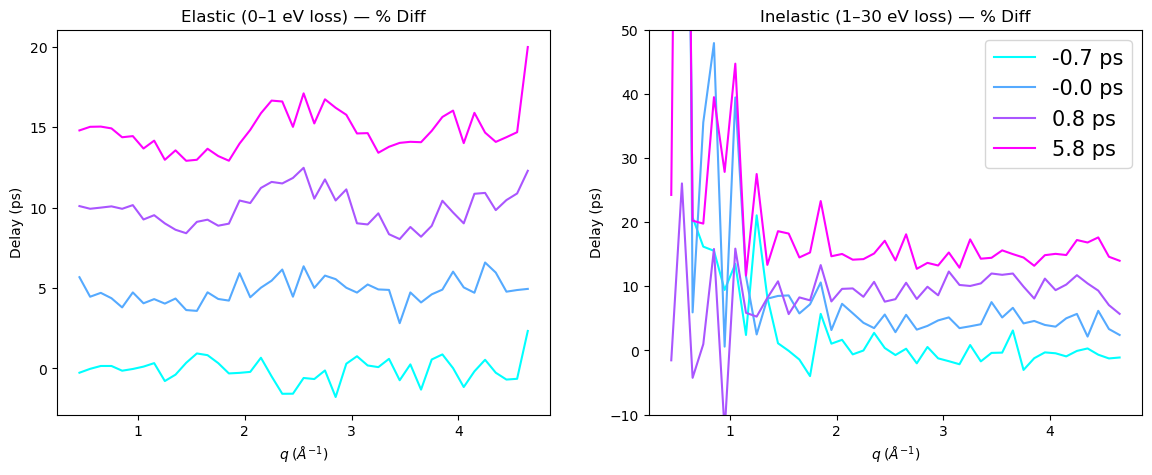

In [71]:
# ################################
# GI_ELASTIC_RANGE  = (0, 1)     # energy-loss range in eV for elastic
# GI_INELASTIC_RANGE = (1, 30)   # energy-loss range in eV for inelastic
# GI_TIME_VOFFSET = 5
# ################################

_E_loss = (E_pix - E_pix[0])*1000

# Build energy masks
_mask_elastic   = (_E_loss >= GI_ELASTIC_RANGE[0])  & (_E_loss < GI_ELASTIC_RANGE[1])
_mask_inelastic = (_E_loss >= GI_INELASTIC_RANGE[0]) & (_E_loss < GI_INELASTIC_RANGE[1])

# Integrate S_spec_abs over the energy ranges  → (q, n_time_groups)
_S_elastic   = S_spec_abs[_mask_elastic, :, :].sum(axis=0)
_S_inelastic = S_spec_abs[_mask_inelastic, :, :].sum(axis=0)

# Percent difference relative to laser-off (time group 0)
_S_elastic_off   = _S_elastic[:, 0]
_S_inelastic_off = _S_inelastic[:, 0]

# Only compute for laser-on groups (indices 1:)
_pct_elastic   = (_S_elastic[:, 1:]   - _S_elastic_off[:, None])   / np.where(_S_elastic_off[:, None] != 0, _S_elastic_off[:, None], np.nan)   * 100
_pct_inelastic = (_S_inelastic[:, 1:] - _S_inelastic_off[:, None]) / np.where(_S_inelastic_off[:, None] != 0, _S_inelastic_off[:, None], np.nan) * 100

# Get profiles by time bin
profiles_elastic = [_pct_elastic.T[t,:] for t in range(n_time_groups-1)]
profiles_inelastic = [_pct_inelastic.T[t,:] for t in range(n_time_groups-1)]

# plot
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for t in range(n_time_groups-1):
    axs[0].plot(q, profiles_elastic[t]+t*GI_TIME_VOFFSET, color=tcolors[t], label=f"{time_bin_labels[t]}")
for t in range(n_time_groups-1):
    axs[1].plot(q, profiles_inelastic[t]+t*GI_TIME_VOFFSET, color=tcolors[t], label=f"{time_bin_labels[t]}")
# axs[1].set_ylim(-10,50)
axs[0].set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",title=f"Elastic ({GI_ELASTIC_RANGE[0]}–{GI_ELASTIC_RANGE[1]} eV loss) — % Diff")
axs[1].set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",title=f"Inelastic ({GI_INELASTIC_RANGE[0]}–{GI_INELASTIC_RANGE[1]} eV loss) — % Diff")
axs[1].set_ylim(-10,50)
plt.legend(fontsize=15)
plt.show()

In [76]:
from scipy.ndimage import gaussian_filter1d

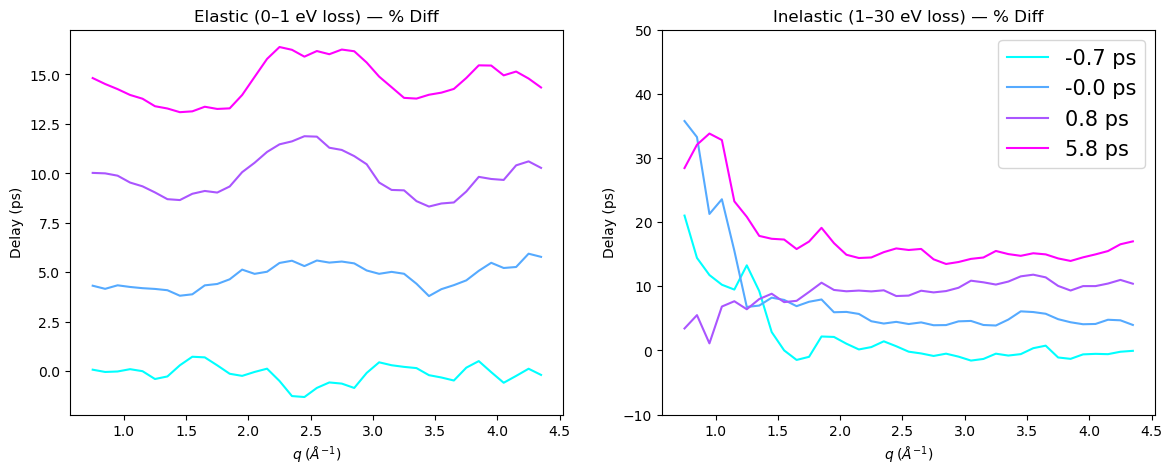

In [84]:
_sigma = 0.8

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for t in range(n_time_groups-1):
    axs[0].plot(q, gaussian_filter1d(profiles_elastic[t],_sigma)+t*GI_TIME_VOFFSET, color=tcolors[t], label=f"{time_bin_labels[t]}")
for t in range(n_time_groups-1):
    axs[1].plot(q, gaussian_filter1d(profiles_inelastic[t],_sigma)+t*GI_TIME_VOFFSET, color=tcolors[t], label=f"{time_bin_labels[t]}")
# axs[1].set_ylim(-10,50)
axs[0].set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",title=f"Elastic ({GI_ELASTIC_RANGE[0]}–{GI_ELASTIC_RANGE[1]} eV loss) — % Diff")
axs[1].set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",title=f"Inelastic ({GI_INELASTIC_RANGE[0]}–{GI_INELASTIC_RANGE[1]} eV loss) — % Diff")
axs[1].set_ylim(-10,50)
plt.legend(fontsize=15)
plt.show()

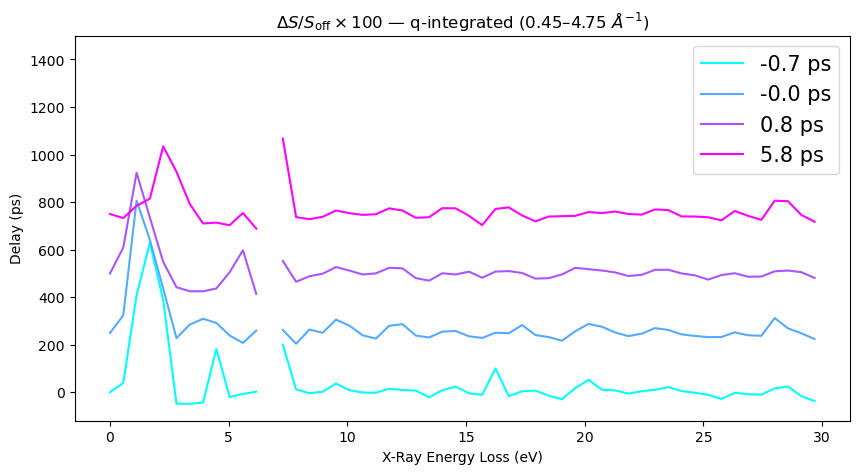

In [69]:
################################
# GI_Q_INTEGRATE_RANGE = (4, None)   # q-index range to integrate over (skip low-q); None = end
################################

_E_loss = (E_pix - E_pix[0])*1000
_q_lo = GI_Q_INTEGRATE_RANGE[0]
_q_hi = GI_Q_INTEGRATE_RANGE[1] if GI_Q_INTEGRATE_RANGE[1] is not None else len(q)

# Integrate S_spec_abs over q range → (energy, n_time_groups)
_S_q_int = S_spec_abs[:, _q_lo:_q_hi, :].sum(axis=1)

# Percent difference relative to laser-off (time group 0)
_S_off_e = _S_q_int[:, 0]
_pct_e = (_S_q_int[:, 1:] - _S_off_e[:, None]) / np.where(_S_off_e[:, None] != 0, _S_off_e[:, None], np.nan) * 100

# get profiles
profiles_energy = [_pct_e.T[t,:] for t in range(n_time_groups-1)]

# plot
fig, ax = plt.subplots(figsize=(10, 5))
for t in range(n_time_groups-1):
    ax.plot(_E_loss, profiles_energy[t]+t*GI_TIME_VOFFSET*50, color=tcolors[t], label=f"{time_bin_labels[t]}")
ax.set_ylim(-120,1500)
ax.set(xlabel="X-Ray Energy Loss (eV)", ylabel="Delay (ps)",
    title=rf"$\Delta S / S_\mathrm{{off}} \times 100$ — q-integrated ({q[_q_lo]:.2f}–{q[_q_hi-1]:.2f} $\AA^{{-1}}$)")
plt.legend(fontsize=15)
plt.show()

In [56]:

# # ---------- User parameters ----------
# GI_ELASTIC_RANGE  = (0, 1)     # energy-loss range in eV for elastic
# GI_INELASTIC_RANGE = (1, 30)   # energy-loss range in eV for inelastic
# GI_CLIM_PCT = 2               # symmetric colour limit (%)
# GI_CLIM_PCT_IN = 50
# # --------------------------------------

# _E_loss = (E_pix - E_pix[0])*1000

# # Build energy masks
# _mask_elastic   = (_E_loss >= GI_ELASTIC_RANGE[0])  & (_E_loss < GI_ELASTIC_RANGE[1])
# _mask_inelastic = (_E_loss >= GI_INELASTIC_RANGE[0]) & (_E_loss < GI_INELASTIC_RANGE[1])

# # Integrate S_spec_abs over the energy ranges  → (q, n_time_groups)
# _S_elastic   = S_spec_abs[_mask_elastic, :, :].sum(axis=0)
# _S_inelastic = S_spec_abs[_mask_inelastic, :, :].sum(axis=0)

# # Percent difference relative to laser-off (time group 0)
# _S_elastic_off   = _S_elastic[:, 0]
# _S_inelastic_off = _S_inelastic[:, 0]

# # Only compute for laser-on groups (indices 1:)
# _on_delays = delay_values[1:]
# _pct_elastic   = (_S_elastic[:, 1:]   - _S_elastic_off[:, None])   / np.where(_S_elastic_off[:, None] != 0, _S_elastic_off[:, None], np.nan)   * 100
# _pct_inelastic = (_S_inelastic[:, 1:] - _S_inelastic_off[:, None]) / np.where(_S_inelastic_off[:, None] != 0, _S_inelastic_off[:, None], np.nan) * 100

# # pcolormesh needs bin edges for q and delay
# _q_edges = np.concatenate([qbins[:len(q)], [qbins[len(q)]]] if len(qbins) > len(q) else [q - np.diff(q, prepend=q[0]-np.diff(q[:2]))/2,
#                            [q[-1] + np.diff(q[-2:])/2]])
# # Simpler: use q bin edges if available, otherwise approximate
# if len(qbins) == len(q) + 1:
#     _q_edges = qbins
# else:
#     _dq = np.diff(q)
#     _q_edges = np.concatenate([[q[0] - _dq[0]/2], (q[:-1] + q[1:])/2, [q[-1] + _dq[-1]/2]])

# _delay_edges = np.arange(len(_on_delays) + 1) - 0.5  # centred integer bins

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# _ax = axes[0]
# _im = _ax.pcolormesh(q, _on_delays, _pct_elastic.T,
#                      cmap="RdBu_r", vmin=-GI_CLIM_PCT, vmax=GI_CLIM_PCT, shading="nearest")
# # _ax.set_yticks(np.arange(len(_on_delays)))
# # _ax.set_yticklabels([f"{d:.2f}" for d in _on_delays])
# _ax.set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",
#         title=f"Elastic ({GI_ELASTIC_RANGE[0]}–{GI_ELASTIC_RANGE[1]} eV loss) — % Diff")
# plt.colorbar(_im, ax=_ax, label="% Difference")

# _ax = axes[1]
# _im = _ax.pcolormesh(q, _on_delays, _pct_inelastic.T,
#                      cmap="RdBu_r", vmin=-GI_CLIM_PCT_IN, vmax=GI_CLIM_PCT_IN, shading="nearest")
# # _ax.set_yticks(np.arange(len(_on_delays)))
# # _ax.set_yticklabels([f"{d:.2f}" for d in _on_delays])
# _ax.set(xlabel=r"$q\;(\AA^{-1})$", ylabel="Delay (ps)",
#         title=f"Inelastic ({GI_INELASTIC_RANGE[0]}–{GI_INELASTIC_RANGE[1]} eV loss) — % Diff")
# plt.colorbar(_im, ax=_ax, label="% Difference")

# plt.suptitle(r"$\Delta S / S_\mathrm{off} \times 100$", fontsize=14)
# plt.tight_layout()
# plt.show()

In [57]:

# # ---------- User parameters ----------
# GI_Q_INTEGRATE_RANGE = (4, None)  # q-index range to integrate over (skip low-q); None = end
# GI_CLIM_PCT_E = 200                # symmetric colour limit (%)
# # --------------------------------------

# _E_loss = (E_pix - E_pix[0])*1000
# _q_lo = GI_Q_INTEGRATE_RANGE[0]
# _q_hi = GI_Q_INTEGRATE_RANGE[1] if GI_Q_INTEGRATE_RANGE[1] is not None else len(q)

# # Integrate S_spec_abs over q range → (energy, n_time_groups)
# _S_q_int = S_spec_abs[:, _q_lo:_q_hi, :].sum(axis=1)

# # Percent difference relative to laser-off (time group 0)
# _S_off_e = _S_q_int[:, 0]
# _pct_e = (_S_q_int[:, 1:] - _S_off_e[:, None]) / np.where(_S_off_e[:, None] != 0, _S_off_e[:, None], np.nan) * 100

# _on_delays = delay_values[1:]

# fig, ax = plt.subplots(figsize=(10, 5))
# _im = ax.pcolormesh(_E_loss, np.arange(len(_on_delays)), _pct_e.T,
#                     cmap="RdBu_r", vmin=-GI_CLIM_PCT_E, vmax=GI_CLIM_PCT_E, shading="nearest")
# ax.set_yticks(np.arange(len(_on_delays)))
# ax.set_yticklabels([f"{d:.2f}" for d in _on_delays])
# ax.set(xlabel="X-Ray Energy Loss (eV)", ylabel="Delay (ps)",
#        title=rf"$\Delta S / S_\mathrm{{off}} \times 100$ — q-integrated ({q[_q_lo]:.2f}–{q[_q_hi-1]:.2f} $\AA^{{-1}}$)")
# plt.colorbar(_im, ax=ax, label="% Difference")
# plt.tight_layout()
# plt.show()
